<a href="https://colab.research.google.com/github/alilabwork-coder/hiv-cd4-tcell-transcriptomics/blob/main/notebooks/02_exploratory_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Python environment is ready.")

Python environment is ready.


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving GSE6740_series_matrix.txt to GSE6740_series_matrix.txt


In [ ]:
from pathlib import Path

matrix_file = Path("GSE6740_series_matrix.txt")

if not matrix_file.exists():
    raise FileNotFoundError(
        "GSE6740_series_matrix.txt was not found. "
        "Please run the upload cell again."
    )

print(f"Using file: {matrix_file}")
print(f"File size: {matrix_file.stat().st_size:,} bytes")

Using file: GSE6740_series_matrix.txt
File size: 3,735,355 bytes


In [ ]:
with open(matrix_file, "r", encoding="utf-8") as handle:
    for _ in range(30):
        print(handle.readline().rstrip())

!Series_title	"Comparison of transcriptional profiles of CD4+ and CD8+ T cells from HIV-infected pateints and uninfected control group"
!Series_geo_accession	"GSE6740"
!Series_status	"Public on Feb 23 2007"
!Series_submission_date	"Jan 12 2007"
!Series_last_update_date	"Aug 10 2018"
!Series_pubmed_id	"17251300"
!Series_summary	"We examined the gene expression profiles in ex vivo human CD4+ and CD8+ T cells from untreated HIV-infected individuals at different clinical stages and rates of disease progression. Profiles of pure CD4+ and CD8+ T cells subsets from HIV-infected nonprogressors who controlled viremia were indistinguishable from HIV-uninfected individuals. Similarly, no gene clusters could distinguish T cells from individuals with early from chronic progressive HIV infection, whereas differences were observed between uninfected or nonprogressors versus early or chronic progressors. In early/chronic HIV infection, three characteristic gene expression signatures were observed: (1)

In [ ]:
with open(matrix_file, "r", encoding="utf-8") as handle:
    for line in handle:
        if line.startswith("!Sample_title"):
            sample_title_line = line.rstrip()
            break

print(sample_title_line)

!Sample_title	"Human Acute HIV Sample A044-CD4 T cells"	"Human Acute HIV Sample A044-CD8+ T cells"	"Human Acute HIV Sample A051-CD4+ T cells"	"Human Acute HIV Sample A051-CD8+ T cells"	"Human Acute HIV Sample A064-CD4+ T cells"	"Human Acute HIV Sample A064-CD8+ T cells"	"Human Acute HIV Sample A144-CD4+ T cells"	"Human Acute HIV Sample A144-CD8+ T cells"	"Human Acute HIV Sample A189-CD4+ T cells"	"Human Acute HIV Sample A189-CD8+ T cells"	"Human Chronic HIV Sample C062-CD4+ T cells"	"Human Chronic HIV Sample C062-CD8+ T cells"	"Human Chronic HIV Sample C080-CD4+ T cells"	"Human Chronic HIV Sample C080-CD8+ T cells"	"Human Chronic HIV Sample C101-CD4+ T cells"	"Human Chronic HIV Sample C101-CD8+ T cells"	"Human Chronic HIV Sample C102-CD4+ T cells"	"Human Chronic HIV Sample C102-CD8+ T cells"	"Human Chronic HIV Sample C138-CD4+ T cells"	"Human Chronic HIV Sample C138-CD8+ T cells"	"Human Non-progressor HIV Sample L004-CD4+ T cells"	"Human Non-progressor HIV Sample L004-CD8+ T cells"	"Hu

In [ ]:
import csv
import re
import pandas as pd

sample_titles = next(csv.reader([sample_title_line], delimiter="\t"))
sample_titles = sample_titles[1:]

metadata_rows = []

for title in sample_titles:
    donor_match = re.search(r"Sample ([A-Z]\d+)", title)
    donor_id = donor_match.group(1) if donor_match else None

    if "Acute HIV" in title:
        clinical_group = "Acute HIV"
        analysis_group = "Progressive HIV"
    elif "Chronic HIV" in title:
        clinical_group = "Chronic progressive HIV"
        analysis_group = "Progressive HIV"
    elif "Non-progressor HIV" in title:
        clinical_group = "HIV non-progressor"
        analysis_group = "Reference"
    elif "Uninfected" in title:
        clinical_group = "HIV-uninfected control"
        analysis_group = "Reference"
    else:
        clinical_group = "Unknown"
        analysis_group = "Unknown"

    if "-CD4" in title:
        cell_type = "CD4+ T cells"
    elif "-CD8" in title:
        cell_type = "CD8+ T cells"
    else:
        cell_type = "Unknown"

    metadata_rows.append(
        {
            "sample_title": title,
            "donor_id": donor_id,
            "cell_type": cell_type,
            "clinical_group": clinical_group,
            "analysis_group": analysis_group,
        }
    )

metadata = pd.DataFrame(metadata_rows)

print("Metadata table shape:", metadata.shape)
display(metadata)

Metadata table shape: (40, 5)


,sample_title,donor_id,cell_type,clinical_group,analysis_group
0,Human Acute HIV Sample A044-CD4 T cells,A044,CD4+ T cells,Acute HIV,Progressive HIV
1,Human Acute HIV Sample A044-CD8+ T cells,A044,CD8+ T cells,Acute HIV,Progressive HIV
2,Human Acute HIV Sample A051-CD4+ T cells,A051,CD4+ T cells,Acute HIV,Progressive HIV
3,Human Acute HIV Sample A051-CD8+ T cells,A051,CD8+ T cells,Acute HIV,Progressive HIV
4,Human Acute HIV Sample A064-CD4+ T cells,A064,CD4+ T cells,Acute HIV,Progressive HIV
5,Human Acute HIV Sample A064-CD8+ T cells,A064,CD8+ T cells,Acute HIV,Progressive HIV
6,Human Acute HIV Sample A144-CD4+ T cells,A144,CD4+ T cells,Acute HIV,Progressive HIV
7,Human Acute HIV Sample A144-CD8+ T cells,A144,CD8+ T cells,Acute HIV,Progressive HIV
8,Human Acute HIV Sample A189-CD4+ T cells,A189,CD4+ T cells,Acute HIV,Progressive HIV
9,Human Acute HIV Sample A189-CD8+ T cells,A189,CD8+ T cells,Acute HIV,Progressive HIV


In [ ]:
summary = (
    metadata
    .groupby(["clinical_group", "cell_type"])
    .size()
    .unstack(fill_value=0)
)

display(summary)

cell_type,CD4+ T cells,CD8+ T cells
clinical_group,,
Acute HIV,5,5
Chronic progressive HIV,5,5
HIV non-progressor,5,5
HIV-uninfected control,5,5


In [ ]:
cd4_metadata = (
    metadata
    .loc[metadata["cell_type"] == "CD4+ T cells"]
    .copy()
    .reset_index(drop=True)
)

print("Number of CD4+ T-cell samples:", len(cd4_metadata))

display(
    cd4_metadata[
        ["sample_title", "donor_id", "clinical_group", "analysis_group"]
    ]
)

Number of CD4+ T-cell samples: 20


,sample_title,donor_id,clinical_group,analysis_group
0,Human Acute HIV Sample A044-CD4 T cells,A044,Acute HIV,Progressive HIV
1,Human Acute HIV Sample A051-CD4+ T cells,A051,Acute HIV,Progressive HIV
2,Human Acute HIV Sample A064-CD4+ T cells,A064,Acute HIV,Progressive HIV
3,Human Acute HIV Sample A144-CD4+ T cells,A144,Acute HIV,Progressive HIV
4,Human Acute HIV Sample A189-CD4+ T cells,A189,Acute HIV,Progressive HIV
5,Human Chronic HIV Sample C062-CD4+ T cells,C062,Chronic progressive HIV,Progressive HIV
6,Human Chronic HIV Sample C080-CD4+ T cells,C080,Chronic progressive HIV,Progressive HIV
7,Human Chronic HIV Sample C101-CD4+ T cells,C101,Chronic progressive HIV,Progressive HIV
8,Human Chronic HIV Sample C102-CD4+ T cells,C102,Chronic progressive HIV,Progressive HIV
9,Human Chronic HIV Sample C138-CD4+ T cells,C138,Chronic progressive HIV,Progressive HIV


In [ ]:
with open(matrix_file, "r", encoding="utf-8") as handle:
    for line in handle:
        if line.startswith("!Sample_geo_accession"):
            sample_accession_line = line.rstrip()
            break

sample_accessions = next(csv.reader([sample_accession_line], delimiter="\t"))
sample_accessions = sample_accessions[1:]

print("Number of GEO sample accessions:", len(sample_accessions))
print(sample_accessions[:10])

Number of GEO sample accessions: 40
['GSM154936', 'GSM155179', 'GSM155180', 'GSM155181', 'GSM155182', 'GSM155183', 'GSM155184', 'GSM155185', 'GSM155186', 'GSM155187']


In [ ]:
metadata["geo_accession"] = sample_accessions

cd4_metadata = (
    metadata
    .loc[metadata["cell_type"] == "CD4+ T cells"]
    .copy()
    .reset_index(drop=True)
)

display(
    cd4_metadata[
        [
            "geo_accession",
            "sample_title",
            "donor_id",
            "clinical_group",
            "analysis_group",
        ]
    ]
)

,geo_accession,sample_title,donor_id,clinical_group,analysis_group
0,GSM154936,Human Acute HIV Sample A044-CD4 T cells,A044,Acute HIV,Progressive HIV
1,GSM155180,Human Acute HIV Sample A051-CD4+ T cells,A051,Acute HIV,Progressive HIV
2,GSM155182,Human Acute HIV Sample A064-CD4+ T cells,A064,Acute HIV,Progressive HIV
3,GSM155184,Human Acute HIV Sample A144-CD4+ T cells,A144,Acute HIV,Progressive HIV
4,GSM155186,Human Acute HIV Sample A189-CD4+ T cells,A189,Acute HIV,Progressive HIV
5,GSM155189,Human Chronic HIV Sample C062-CD4+ T cells,C062,Chronic progressive HIV,Progressive HIV
6,GSM155192,Human Chronic HIV Sample C080-CD4+ T cells,C080,Chronic progressive HIV,Progressive HIV
7,GSM155200,Human Chronic HIV Sample C101-CD4+ T cells,C101,Chronic progressive HIV,Progressive HIV
8,GSM155202,Human Chronic HIV Sample C102-CD4+ T cells,C102,Chronic progressive HIV,Progressive HIV
9,GSM155204,Human Chronic HIV Sample C138-CD4+ T cells,C138,Chronic progressive HIV,Progressive HIV


In [ ]:
group_counts = (
    cd4_metadata["analysis_group"]
    .value_counts()
    .rename_axis("analysis_group")
    .reset_index(name="n_samples")
)

display(group_counts)

,analysis_group,n_samples
0,Progressive HIV,10
1,Reference,10


In [ ]:
table_start_row = None

with open(matrix_file, "r", encoding="utf-8") as handle:
    for row_number, line in enumerate(handle):
        if line.startswith('"ID_REF"'):
            table_start_row = row_number
            break

print("Expression table starts at row:", table_start_row)

Expression table starts at row: 67


In [ ]:
expression = pd.read_csv(
    matrix_file,
    sep="\t",
    skiprows=table_start_row,
    index_col=0,
    na_values="null",
)

expression = expression.loc[
    ~expression.index.astype(str).str.startswith("!series_matrix_table_end")
]

print("Expression matrix shape:", expression.shape)
print("First five sample columns:", expression.columns[:5].tolist())
display(expression.iloc[:5, :5])

Expression matrix shape: (22283, 40)
First five sample columns: ['GSM154936', 'GSM155179', 'GSM155180', 'GSM155181', 'GSM155182']


,GSM154936,GSM155179,GSM155180,GSM155181,GSM155182
ID_REF,,,,,
1007_s_at,344.0,242.0,326.0,318.0,285.0
1053_at,319.0,296.0,389.0,342.0,315.0
117_at,171.0,159.0,89.0,162.0,158.0
121_at,1028.0,871.0,1348.0,1243.0,1152.0
1255_g_at,71.0,10.0,90.0,50.0,36.0


In [ ]:
cd4_sample_ids = cd4_metadata["geo_accession"].tolist()

missing_ids = sorted(set(cd4_sample_ids) - set(expression.columns))

print("CD4+ metadata samples:", len(cd4_sample_ids))
print("CD4+ sample IDs found in expression matrix:", len(cd4_sample_ids) - len(missing_ids))
print("Missing sample IDs:", missing_ids)

CD4+ metadata samples: 20
CD4+ sample IDs found in expression matrix: 20
Missing sample IDs: []


In [ ]:
cd4_expression = expression.loc[:, cd4_sample_ids].copy()

print("CD4+ expression matrix shape:", cd4_expression.shape)
display(cd4_expression.iloc[:5, :5])

CD4+ expression matrix shape: (22283, 20)


,GSM154936,GSM155180,GSM155182,GSM155184,GSM155186
ID_REF,,,,,
1007_s_at,344.0,326.0,285.0,374.0,377.0
1053_at,319.0,389.0,315.0,259.0,216.0
117_at,171.0,89.0,158.0,145.0,87.0
121_at,1028.0,1348.0,1152.0,1983.0,1142.0
1255_g_at,71.0,90.0,36.0,118.0,41.0


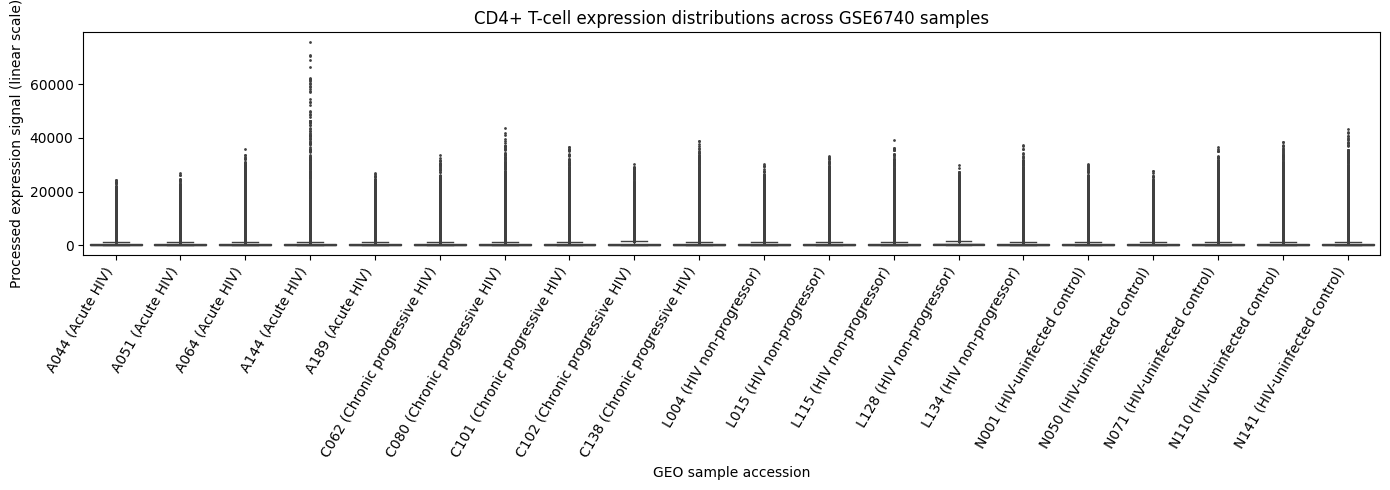

In [ ]:
plt.figure(figsize=(14, 5))

sns.boxplot(
    data=cd4_expression,
    color="steelblue",
    fliersize=1
)

plt.xticks(
    ticks=range(len(sample_labels)),
    labels=sample_labels,
    rotation=60,
    ha="right"
)

plt.xlabel("GEO sample accession")
plt.ylabel("Processed expression signal (linear scale)")
plt.title("CD4+ T-cell expression distributions across GSE6740 samples")
plt.tight_layout()
plt.show()

In [ ]:
sample_labels = (
    cd4_metadata
    .set_index("geo_accession")
    .loc[cd4_expression.columns]
    .apply(
        lambda row: f"{row['donor_id']} ({row['clinical_group']})",
        axis=1
    )
)

display(sample_labels.to_frame(name="plot_label"))

,plot_label
GSM154936,A044 (Acute HIV)
GSM155180,A051 (Acute HIV)
GSM155182,A064 (Acute HIV)
GSM155184,A144 (Acute HIV)
GSM155186,A189 (Acute HIV)
GSM155189,C062 (Chronic progressive HIV)
GSM155192,C080 (Chronic progressive HIV)
GSM155200,C101 (Chronic progressive HIV)
GSM155202,C102 (Chronic progressive HIV)
GSM155204,C138 (Chronic progressive HIV)


In [ ]:
cd4_expression_log2 = np.log2(cd4_expression + 1)

print(
    "Log2-transformed expression range:",
    f"{cd4_expression_log2.min().min():.2f}",
    "to",
    f"{cd4_expression_log2.max().max():.2f}",
)

Log2-transformed expression range: 0.00 to 16.21


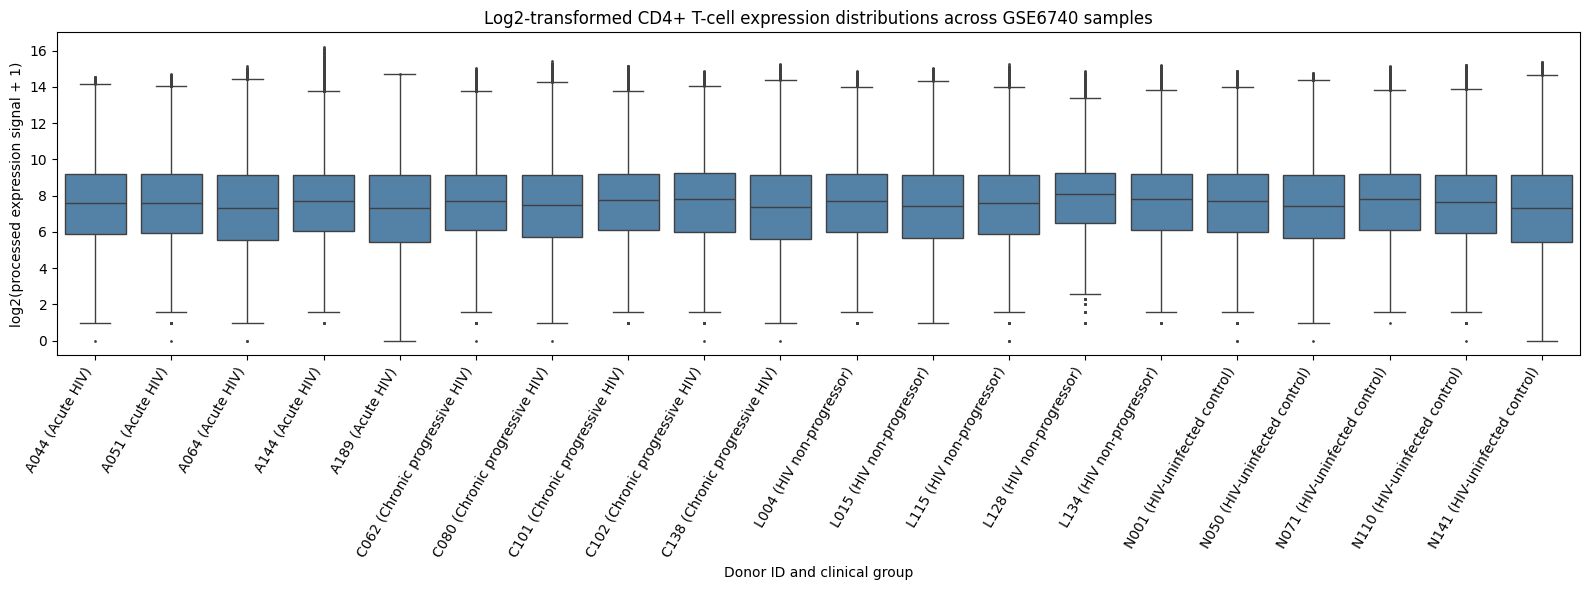

In [ ]:
plt.figure(figsize=(16, 6))

sns.boxplot(
    data=cd4_expression_log2,
    color="steelblue",
    fliersize=1
)

plt.xticks(
    ticks=range(len(sample_labels)),
    labels=sample_labels,
    rotation=60,
    ha="right"
)

plt.xlabel("Donor ID and clinical group")
plt.ylabel("log2(processed expression signal + 1)")
plt.title("Log2-transformed CD4+ T-cell expression distributions across GSE6740 samples")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaled_samples = StandardScaler().fit_transform(cd4_expression_log2.T)

pca = PCA(n_components=2)
pca_scores = pca.fit_transform(scaled_samples)

pca_df = cd4_metadata[
    ["geo_accession", "donor_id", "clinical_group", "analysis_group"]
].copy()

pca_df["PC1"] = pca_scores[:, 0]
pca_df["PC2"] = pca_scores[:, 1]

print(
    "Variance explained by PC1:",
    f"{pca.explained_variance_ratio_[0] * 100:.1f}%"
)
print(
    "Variance explained by PC2:",
    f"{pca.explained_variance_ratio_[1] * 100:.1f}%"
)

display(pca_df)

Variance explained by PC1: 22.6%
Variance explained by PC2: 11.1%


,geo_accession,donor_id,clinical_group,analysis_group,PC1,PC2
0,GSM154936,A044,Acute HIV,Progressive HIV,5.607406,34.927528
1,GSM155180,A051,Acute HIV,Progressive HIV,2.211126,-2.802465
2,GSM155182,A064,Acute HIV,Progressive HIV,-82.894998,22.748014
3,GSM155184,A144,Acute HIV,Progressive HIV,64.842921,-153.298012
4,GSM155186,A189,Acute HIV,Progressive HIV,-101.825038,3.257331
5,GSM155189,C062,Chronic progressive HIV,Progressive HIV,22.284808,-79.389164
6,GSM155192,C080,Chronic progressive HIV,Progressive HIV,-50.130145,23.874056
7,GSM155200,C101,Chronic progressive HIV,Progressive HIV,21.496395,-39.430627
8,GSM155202,C102,Chronic progressive HIV,Progressive HIV,120.997193,79.436029
9,GSM155204,C138,Chronic progressive HIV,Progressive HIV,-84.305136,-1.312628


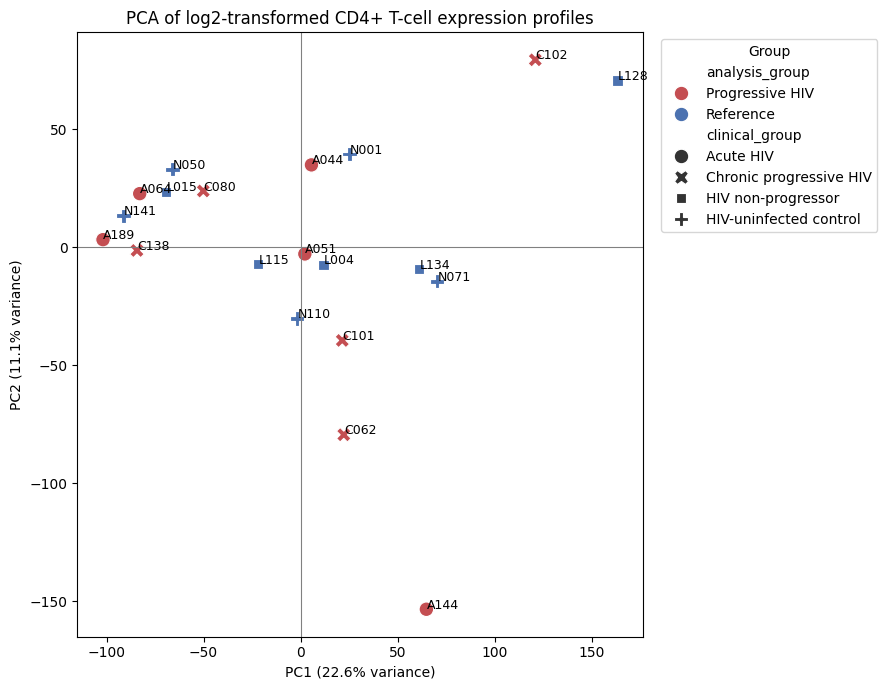

In [ ]:
plt.figure(figsize=(9, 7))

palette = {
    "Progressive HIV": "#c44e52",
    "Reference": "#4c72b0",
}

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="analysis_group",
    style="clinical_group",
    palette=palette,
    s=110
)

for _, row in pca_df.iterrows():
    plt.text(
        row["PC1"] + 0.2,
        row["PC2"] + 0.2,
        row["donor_id"],
        fontsize=9
    )

plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
plt.title("PCA of log2-transformed CD4+ T-cell expression profiles")
plt.legend(title="Group", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
pca_df["distance_from_center"] = np.sqrt(
    pca_df["PC1"] ** 2 + pca_df["PC2"] ** 2
)

outlier_ranking = (
    pca_df[
        [
            "donor_id",
            "clinical_group",
            "analysis_group",
            "PC1",
            "PC2",
            "distance_from_center",
        ]
    ]
    .sort_values("distance_from_center", ascending=False)
    .reset_index(drop=True)
)

display(outlier_ranking)

,donor_id,clinical_group,analysis_group,PC1,PC2,distance_from_center
0,L128,HIV non-progressor,Reference,163.302308,70.622571,177.919058
1,A144,Acute HIV,Progressive HIV,64.842921,-153.298012,166.447844
2,C102,Chronic progressive HIV,Progressive HIV,120.997193,79.436029,144.742541
3,A189,Acute HIV,Progressive HIV,-101.825038,3.257331,101.877125
4,N141,HIV-uninfected control,Reference,-91.291315,13.316078,92.257369
5,A064,Acute HIV,Progressive HIV,-82.894998,22.748014,85.959600
6,C138,Chronic progressive HIV,Progressive HIV,-84.305136,-1.312628,84.315354
7,C062,Chronic progressive HIV,Progressive HIV,22.284808,-79.389164,82.457577
8,N050,HIV-uninfected control,Reference,-65.873384,33.150233,73.744428
9,L015,HIV non-progressor,Reference,-69.231910,23.474178,73.103313


In [ ]:
sensitivity_metadata = (
    cd4_metadata
    .loc[cd4_metadata["donor_id"] != "A144"]
    .copy()
    .reset_index(drop=True)
)

sensitivity_sample_ids = sensitivity_metadata["geo_accession"].tolist()

sensitivity_expression = cd4_expression_log2.loc[:, sensitivity_sample_ids]

scaled_sensitivity = StandardScaler().fit_transform(
    sensitivity_expression.T
)

pca_sensitivity = PCA(n_components=2)
scores_sensitivity = pca_sensitivity.fit_transform(
    scaled_sensitivity
)

pca_sensitivity_df = sensitivity_metadata[
    [
        "geo_accession",
        "donor_id",
        "clinical_group",
        "analysis_group",
    ]
].copy()

pca_sensitivity_df["PC1"] = scores_sensitivity[:, 0]
pca_sensitivity_df["PC2"] = scores_sensitivity[:, 1]

print(
    "Variance explained without A144:",
    f"PC1 = {pca_sensitivity.explained_variance_ratio_[0] * 100:.1f}%,",
    f"PC2 = {pca_sensitivity.explained_variance_ratio_[1] * 100:.1f}%"
)

Variance explained without A144: PC1 = 23.8%, PC2 = 10.0%


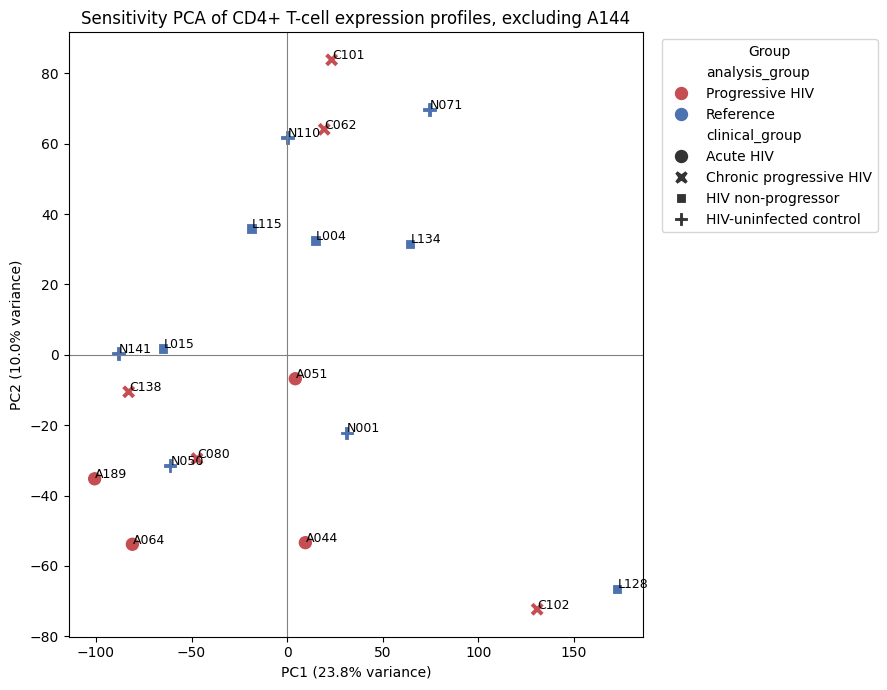

In [ ]:
plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=pca_sensitivity_df,
    x="PC1",
    y="PC2",
    hue="analysis_group",
    style="clinical_group",
    palette={
        "Progressive HIV": "#c44e52",
        "Reference": "#4c72b0",
    },
    s=110
)

for _, row in pca_sensitivity_df.iterrows():
    plt.text(
        row["PC1"] + 0.2,
        row["PC2"] + 0.2,
        row["donor_id"],
        fontsize=9
    )

plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.xlabel(
    f"PC1 ({pca_sensitivity.explained_variance_ratio_[0] * 100:.1f}% variance)"
)
plt.ylabel(
    f"PC2 ({pca_sensitivity.explained_variance_ratio_[1] * 100:.1f}% variance)"
)
plt.title("Sensitivity PCA of CD4+ T-cell expression profiles, excluding A144")
plt.legend(title="Group", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### PCA quality-control interpretation

PCA of log2-transformed CD4+ T-cell expression profiles identified donor A144
(acute HIV infection) as a transcriptome-wide outlier, primarily along PC2.
The sample was retained in the primary analysis because PCA alone cannot distinguish
technical artifact from meaningful biological heterogeneity. A sensitivity analysis
excluding A144 will assess whether downstream differential-expression findings are
robust to this observation.

## Quality-control interpretation

Log2-transformed expression distributions were broadly comparable across the 20 CD4+ T-cell samples. PCA of all samples identified acute-HIV donor A144 as a transcriptome-wide outlier, predominantly along PC2. Because PCA cannot determine whether this pattern represents technical artifact or biological heterogeneity, A144 was retained in the primary analysis.

A sensitivity PCA excluding A144 altered sample geometry but did not produce complete separation between progressive-HIV and reference groups. This indicates substantial inter-individual heterogeneity in this small public cohort. Downstream gene-level results will therefore be presented as exploratory and evaluated with sensitivity analyses where feasible.

In [ ]:
cd4_metadata.to_csv(
    "cd4_sample_metadata.csv",
    index=False
)

print("Saved: cd4_sample_metadata.csv")
display(cd4_metadata)

Saved: cd4_sample_metadata.csv


,sample_title,donor_id,cell_type,clinical_group,analysis_group,geo_accession
0,Human Acute HIV Sample A044-CD4 T cells,A044,CD4+ T cells,Acute HIV,Progressive HIV,GSM154936
1,Human Acute HIV Sample A051-CD4+ T cells,A051,CD4+ T cells,Acute HIV,Progressive HIV,GSM155180
2,Human Acute HIV Sample A064-CD4+ T cells,A064,CD4+ T cells,Acute HIV,Progressive HIV,GSM155182
3,Human Acute HIV Sample A144-CD4+ T cells,A144,CD4+ T cells,Acute HIV,Progressive HIV,GSM155184
4,Human Acute HIV Sample A189-CD4+ T cells,A189,CD4+ T cells,Acute HIV,Progressive HIV,GSM155186
5,Human Chronic HIV Sample C062-CD4+ T cells,C062,CD4+ T cells,Chronic progressive HIV,Progressive HIV,GSM155189
6,Human Chronic HIV Sample C080-CD4+ T cells,C080,CD4+ T cells,Chronic progressive HIV,Progressive HIV,GSM155192
7,Human Chronic HIV Sample C101-CD4+ T cells,C101,CD4+ T cells,Chronic progressive HIV,Progressive HIV,GSM155200
8,Human Chronic HIV Sample C102-CD4+ T cells,C102,CD4+ T cells,Chronic progressive HIV,Progressive HIV,GSM155202
9,Human Chronic HIV Sample C138-CD4+ T cells,C138,CD4+ T cells,Chronic progressive HIV,Progressive HIV,GSM155204


In [ ]:
from google.colab import files

files.download("cd4_sample_metadata.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>